# Exploratory Data Analysis

Last.fm HetRec 2011. The dataset has four parts and this notebook explores all of them: **listening** (user-artist plays), **tags** (genres/descriptors feeding content-based filtering), and **friendships** (feeding the social recommender), plus data-quality checks. All statistics come from tested helpers in `recsys.data.eda`; figures are saved to `docs/figures/` for the report.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from recsys.config import (RAW_DIR, PROCESSED_DIR, ARTISTS_FILE, TAGS_FILE,
    USER_ARTISTS_FILE, USER_TAGGED_ARTISTS_FILE, USER_FRIENDS_FILE,
    WEIGHT_COL, ITEM_COL, USER_COL)
from recsys.data.loader import (load_user_artists, load_artists, load_tags,
    load_user_tagged_artists, load_user_friends)
from recsys.data import eda

sns.set_theme(style='whitegrid')
FIG_DIR = PROCESSED_DIR.parents[1] / 'docs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

interactions = load_user_artists(RAW_DIR / USER_ARTISTS_FILE)
artists = load_artists(RAW_DIR / ARTISTS_FILE)
tags = load_tags(RAW_DIR / TAGS_FILE)
tagged = load_user_tagged_artists(RAW_DIR / USER_TAGGED_ARTISTS_FILE)
friends = load_user_friends(RAW_DIR / USER_FRIENDS_FILE)
interactions['log_weight'] = np.log1p(interactions[WEIGHT_COL])
interactions.head()

,user_id,artist_id,weight,log_weight
0,2,51,13883,9.538492
1,2,52,11690,9.366575
2,2,53,11351,9.337149
3,2,54,10300,9.239996
4,2,55,8983,9.103200


## 1. Summary statistics

Dataset size, sparsity, and the popularity-concentration Gini.

In [2]:
pd.Series(eda.summary_stats(interactions)).to_frame('value')

,value
n_users,1892.000000
n_items,17632.000000
n_interactions,92834.000000
density,0.002783
sparsity,0.997217
median_artists_per_user,50.000000
median_listeners_per_artist,1.000000
plays_gini,0.892666


## 2. Data quality and outliers

No duplicate user-artist pairs or non-positive weights. Play counts are extremely skewed: the median is a few hundred but the maximum is a single super-fan with hundreds of thousands of plays - which is exactly why we log-scale before modelling.

In [3]:
q = eda.interaction_quality(interactions)
display(pd.Series(q).to_frame('value'))
print('Play-count percentiles:')
print(interactions[WEIGHT_COL].describe(percentiles=[.5,.9,.99,.999]).round(1))

,value
n_rows,92834.0
n_duplicate_pairs,0.0
n_nonpositive_weight,0.0
min_weight,1.0
median_weight,260.0
max_weight,352698.0


Play-count percentiles:
count     92834.0
mean        745.2
std        3751.3
min           1.0
50%         260.0
90%        1387.0
99%        7228.0
99.9%     38672.5
max      352698.0
Name: weight, dtype: float64


## 3. Play-count distribution (the implicit signal)

Raw counts span several orders of magnitude; log(1+plays) tames the tail.

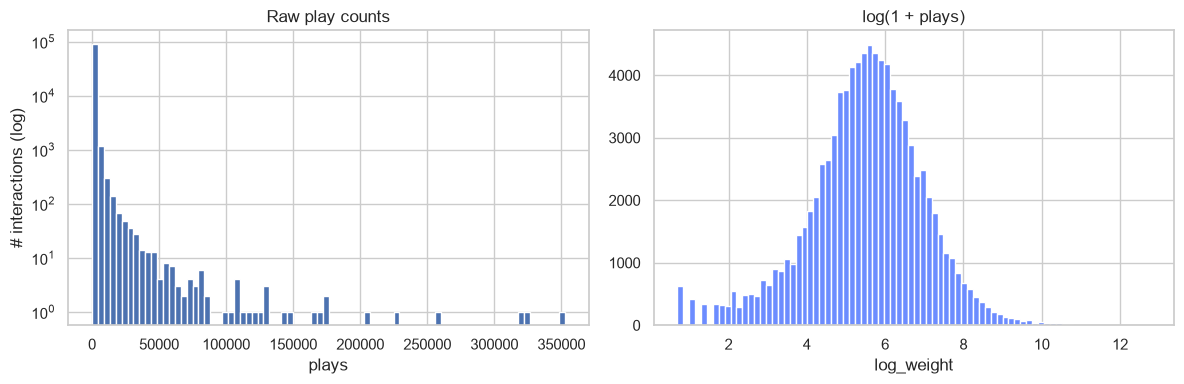

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(interactions[WEIGHT_COL], bins=80); axes[0].set_yscale('log')
axes[0].set_title('Raw play counts'); axes[0].set_xlabel('plays'); axes[0].set_ylabel('# interactions (log)')
axes[1].hist(interactions['log_weight'], bins=80, color='#6c8cff')
axes[1].set_title('log(1 + plays)'); axes[1].set_xlabel('log_weight')
fig.tight_layout(); fig.savefig(FIG_DIR/'play_count_distribution.png', dpi=120); plt.show()

## 4. How active are users and artists?

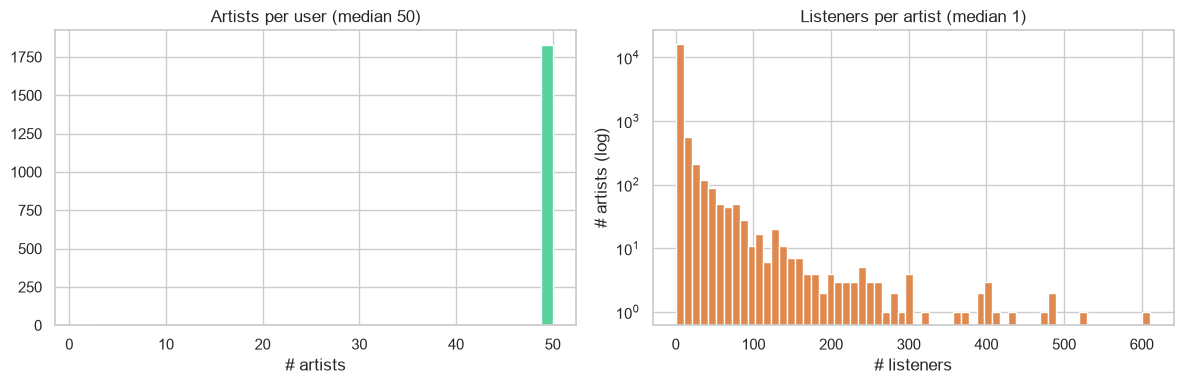

In [5]:
per_user = interactions.groupby(USER_COL).size()
per_item = interactions.groupby(ITEM_COL).size()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(per_user, bins=40, color='#5ad19a'); axes[0].set_title(f'Artists per user (median {per_user.median():.0f})'); axes[0].set_xlabel('# artists')
axes[1].hist(per_item, bins=60, color='#e0894f'); axes[1].set_yscale('log')
axes[1].set_title(f'Listeners per artist (median {per_item.median():.0f})'); axes[1].set_xlabel('# listeners'); axes[1].set_ylabel('# artists (log)')
fig.tight_layout(); fig.savefig(FIG_DIR/'activity_distributions.png', dpi=120); plt.show()

## 5. Long tail and popularity bias

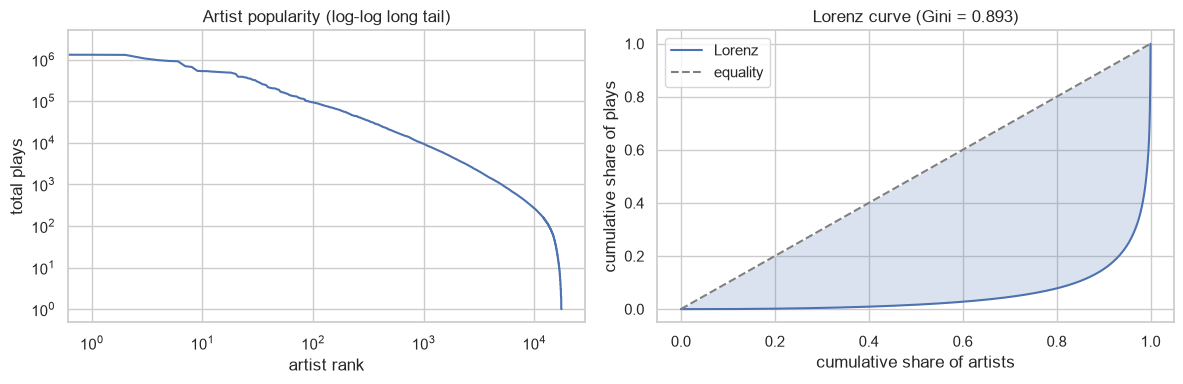

Top 50 artists capture 34.8% of all plays
Top 100 artists capture 43.7% of all plays
Top 500 artists capture 67.9% of all plays


In [6]:
curve = eda.popularity_curve(interactions); g = eda.summary_stats(interactions)['plays_gini']
sorted_plays = np.sort(curve.values); cum = np.cumsum(sorted_plays)/sorted_plays.sum(); cum = np.insert(cum,0,0)
x = np.linspace(0,1,len(cum))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(curve.values); axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_title('Artist popularity (log-log long tail)'); axes[0].set_xlabel('artist rank'); axes[0].set_ylabel('total plays')
axes[1].plot(x, cum, label='Lorenz'); axes[1].plot([0,1],[0,1],'--',color='gray',label='equality'); axes[1].fill_between(x,cum,x,alpha=0.2)
axes[1].set_title(f'Lorenz curve (Gini = {g:.3f})'); axes[1].set_xlabel('cumulative share of artists'); axes[1].set_ylabel('cumulative share of plays'); axes[1].legend()
fig.tight_layout(); fig.savefig(FIG_DIR/'long_tail_lorenz.png', dpi=120); plt.show()
for k in (50,100,500): print(f'Top {k} artists capture {eda.top_k_play_share(interactions,k):.1%} of all plays')

## 6. Most popular artists and most active users

In [7]:
plays_by_artist = interactions.groupby(ITEM_COL)[WEIGHT_COL].sum().sort_values(ascending=False)
top10 = plays_by_artist.head(10).reset_index().merge(artists, on=ITEM_COL)
display(top10[['name', WEIGHT_COL]])
display(eda.most_active_users(interactions, n=10))

,name,weight
0,Britney Spears,2393140
1,Depeche Mode,1301308
2,Lady Gaga,1291387
3,Christina Aguilera,1058405
4,Paramore,963449
5,Madonna,921198
6,Rihanna,905423
7,Shakira,688529
8,The Beatles,662116
9,Katy Perry,532545


,user_id,n_artists,total_plays
0,2,50,168737
1,1376,50,1106
2,1388,50,4453
3,1387,50,8947
4,1386,50,9450
5,1385,50,7169
6,1384,50,39464
7,1383,50,34246
8,1382,50,54095
9,1381,50,7673


## 7. Tags and the genre landscape

Tags are the metadata behind content-based filtering. They are themselves long-tailed, and - importantly - **not every artist is tagged**, which limits content-based coverage.

9749 distinct tags used across 186,479 assignments
5,109 of 17,632 artists (29%) have no tags - invisible to content-based filtering


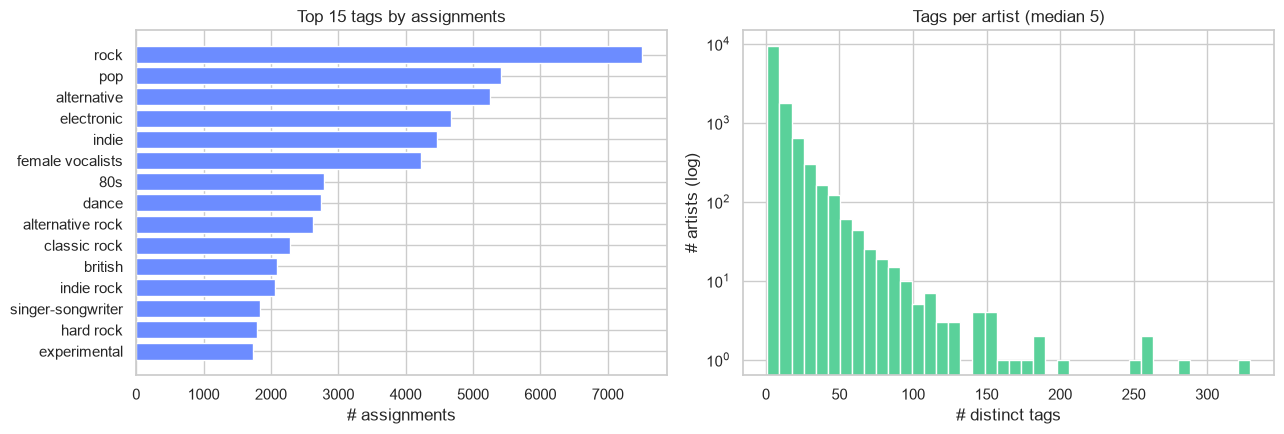

In [8]:
freq = eda.tag_frequency(tagged, tags, n=15)
tpa = eda.tags_per_artist(tagged)
untagged = len(artists) - tagged[ITEM_COL].nunique()
print(f"{tagged['tag_id'].nunique()} distinct tags used across {len(tagged):,} assignments")
print(f"{untagged:,} of {len(artists):,} artists ({untagged/len(artists):.0%}) have no tags - invisible to content-based filtering")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(freq['tag'][::-1], freq['assignments'][::-1], color='#6c8cff')
axes[0].set_title('Top 15 tags by assignments'); axes[0].set_xlabel('# assignments')
axes[1].hist(tpa, bins=40, color='#5ad19a'); axes[1].set_yscale('log')
axes[1].set_title(f'Tags per artist (median {tpa.median():.0f})'); axes[1].set_xlabel('# distinct tags'); axes[1].set_ylabel('# artists (log)')
fig.tight_layout(); fig.savefig(FIG_DIR/'tag_analysis.png', dpi=120); plt.show()

## 8. The friendship graph

The social signal behind the social recommender. The key question: **do friends actually listen alike?** We compare the listening overlap (Jaccard of artist sets) of friend pairs against random user pairs.

25,434 friendship edges; mean 13.4 friends/user, max 119
Friend-pair listening overlap (Jaccard): 0.103
Random-pair listening overlap (Jaccard): 0.024
-> friends overlap 4.3x more than random pairs (this justifies the social recommender)


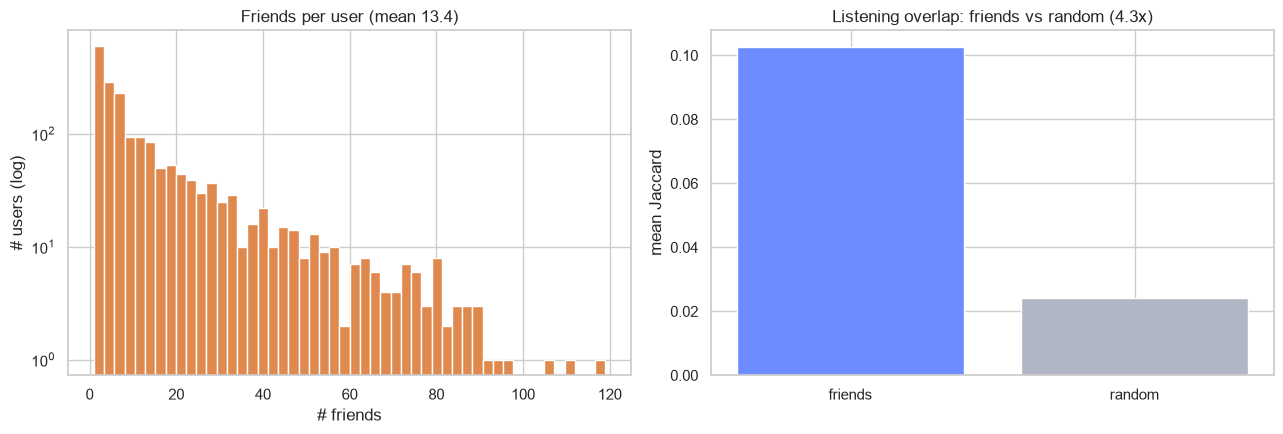

In [9]:
degree = eda.friend_degree(friends)
overlap = eda.friend_listening_overlap(interactions, friends)
print(f"{len(friends):,} friendship edges; mean {degree.mean():.1f} friends/user, max {degree.max()}")
print(f"Friend-pair listening overlap (Jaccard): {overlap['friend_jaccard']:.3f}")
print(f"Random-pair listening overlap (Jaccard): {overlap['random_jaccard']:.3f}")
print(f"-> friends overlap {overlap['ratio']:.1f}x more than random pairs (this justifies the social recommender)")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(degree, bins=50, color='#e0894f'); axes[0].set_yscale('log')
axes[0].set_title(f'Friends per user (mean {degree.mean():.1f})'); axes[0].set_xlabel('# friends'); axes[0].set_ylabel('# users (log)')
axes[1].bar(['friends','random'], [overlap['friend_jaccard'], overlap['random_jaccard']], color=['#6c8cff','#b0b6c4'])
axes[1].set_title(f'Listening overlap: friends vs random ({overlap["ratio"]:.1f}x)'); axes[1].set_ylabel('mean Jaccard')
fig.tight_layout(); fig.savefig(FIG_DIR/'friendship_analysis.png', dpi=120); plt.show()

## Takeaways

- **Listening:** ~99.7% sparse, Gini 0.893, a brutal long tail (median artist has one listener). Play counts are heavy-tailed with extreme outliers - log-scaling / confidence weighting is justified.
- **Tags:** long-tailed too, and ~29% of artists are untagged - a real ceiling on content-based coverage.
- **Friendships:** dense (mean ~13 friends) and meaningful - friends listen ~4x more alike than random users, which is the empirical basis for the social recommender.
- **Data quality:** no duplicates or invalid weights; the only quirk is the extreme play-count skew.